# 📊 Supply Chain Analytics — Análise Exploratória de Dados

**Autor:** Felipe Comenale Banciella
**Contexto:** Estagiário em Demand Planning @ Unilever | Estudante de Análise e Desenvolvimento de Sistemas

---

## 🎯 Contexto de Negócio

Este projeto simula o dia a dia de um time de **Demand Planning / Supply Chain** em uma
indústria de bens de consumo. A partir de dados de **pedidos, estoque, entregas e produtos**,
o objetivo é extrair insights acionáveis que apoiem a tomada de decisão do time.

> ⚠️ **Todos os dados são fictícios**, gerados artificialmente para fins de portfólio.
> Nenhum dado real de qualquer empresa foi utilizado.

## ❓ Perguntas de Negócio que vamos responder

1. **Vendas** — Quais marcas, categorias, regiões e canais mais faturam?
2. **Sazonalidade** — Como as vendas evoluem ao longo dos meses? Há tendência?
3. **Ruptura de estoque** — Quais SKUs estão em risco? Existe relação entre estoque e demanda?
4. **Performance de entrega (OTIF)** — Quais marcas e transportadoras entregam pior?
5. **SKUs críticos** — Quais produtos exigem ação imediata (alta demanda + baixo estoque)?
6. **Bônus** — Uma previsão simples de demanda usando média móvel.

## 🛠️ Stack
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn`


## 1️⃣ Setup e Carga dos Dados

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

print("Bibliotecas carregadas com sucesso ✅")

/opt/oai-pkgs/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


Bibliotecas carregadas com sucesso ✅


In [2]:
# Caminho dos dados (ajuste se necessário)
PATH = "../data/raw"

produtos = pd.read_csv(f"{PATH}/produtos.csv")
pedidos  = pd.read_csv(f"{PATH}/pedidos.csv")
estoque  = pd.read_csv(f"{PATH}/estoque.csv")
entregas = pd.read_csv(f"{PATH}/entregas.csv")

print("Shapes dos datasets:")
print(f"  produtos : {produtos.shape}")
print(f"  pedidos  : {pedidos.shape}")
print(f"  estoque  : {estoque.shape}")
print(f"  entregas : {entregas.shape}")

Shapes dos datasets:
  produtos : (25, 6)
  pedidos  : (5000, 7)
  estoque  : (650, 5)
  entregas : (5000, 5)


### 👀 Primeira olhada nos dados

In [3]:
produtos.head()

,sku,descricao_produto,marca,categoria,formato,preco_unitario
0,SKU0001,Dove Sabonete 90g,Dove,Cuidados Pessoais,Sabonete 90g,4.5
1,SKU0002,Dove Shampoo 400ml,Dove,Cuidados Pessoais,Shampoo 400ml,21.9
2,SKU0003,Dove Condicionador 400ml,Dove,Cuidados Pessoais,Condicionador 400ml,22.9
3,SKU0004,Dove Desodorante 150ml,Dove,Cuidados Pessoais,Desodorante 150ml,18.5
4,SKU0005,Rexona Desodorante 150ml,Rexona,Cuidados Pessoais,Desodorante 150ml,16.9


In [4]:
pedidos.head()

,id_pedido,data_pedido,sku,quantidade,canal_venda,regiao,id_cliente
0,PED000001,2025-05-26,SKU0024,48,Grande Varejo,Sudeste,CLI0270
1,PED000002,2025-04-05,SKU0002,6,Farmácia,Sudeste,CLI0190
2,PED000003,2025-02-09,SKU0018,12,Atacado,Nordeste,CLI0280
3,PED000004,2025-06-03,SKU0018,6,Distribuidor,Sudeste,CLI0157
4,PED000005,2025-01-15,SKU0001,12,E-commerce,Sudeste,CLI0129


## 2️⃣ Preparação e Qualidade dos Dados

Antes de analisar, precisamos garantir que os dados estão consistentes: tipos corretos,
datas convertidas, checagem de nulos e criação de colunas derivadas úteis para a análise.

In [5]:
# Checando valores nulos
print("Valores nulos por dataset:\n")
for nome, df in [("produtos", produtos), ("pedidos", pedidos),
                 ("estoque", estoque), ("entregas", entregas)]:
    print(f"--- {nome} ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0
          else "  Sem nulos")
    print()

Valores nulos por dataset:

--- produtos ---
  Sem nulos

--- pedidos ---
  Sem nulos

--- estoque ---
  Sem nulos

--- entregas ---
data_entregue    239
dtype: int64



In [6]:
# Conversão de datas
pedidos["data_pedido"] = pd.to_datetime(pedidos["data_pedido"])
estoque["data_referencia"] = pd.to_datetime(estoque["data_referencia"])
entregas["data_prometida"] = pd.to_datetime(entregas["data_prometida"])
entregas["data_entregue"] = pd.to_datetime(entregas["data_entregue"])

# Colunas derivadas em pedidos
pedidos["ano_mes"] = pedidos["data_pedido"].dt.strftime("%Y-%m")
pedidos["mes"] = pedidos["data_pedido"].dt.month

# Junta info de produto (marca, categoria, preço) nos pedidos
pedidos = pedidos.merge(
    produtos[["sku", "marca", "categoria", "preco_unitario"]],
    on="sku", how="left"
)
pedidos["valor_total"] = (pedidos["quantidade"] * pedidos["preco_unitario"]).round(2)

print("Colunas de pedidos após enriquecimento:")
print(list(pedidos.columns))

Colunas de pedidos após enriquecimento:
['id_pedido', 'data_pedido', 'sku', 'quantidade', 'canal_venda', 'regiao', 'id_cliente', 'ano_mes', 'mes', 'marca', 'categoria', 'preco_unitario', 'valor_total']


In [7]:
# Enriquecimento de estoque e entregas
estoque["status_ruptura"] = np.where(
    estoque["quantidade_disponivel"] < estoque["ponto_reposicao"], "EM RISCO", "OK")
estoque["pct_cobertura"] = (
    estoque["quantidade_disponivel"] / estoque["ponto_reposicao"] * 100).round(2)

entregas["atraso_dias"] = (entregas["data_entregue"] - entregas["data_prometida"]).dt.days
entregas["entrega_no_prazo"] = np.where(
    entregas["atraso_dias"].notna() & (entregas["atraso_dias"] <= 0), 1, 0)

print("Dados preparados e enriquecidos ✅")

Dados preparados e enriquecidos ✅


## 3️⃣ Visão Geral do Negócio

Vamos começar com os números macro: faturamento total, volume de pedidos e ticket médio.

In [8]:
fat_total = pedidos["valor_total"].sum()
qtd_pedidos = pedidos["id_pedido"].nunique()
qtd_unidades = pedidos["quantidade"].sum()
ticket_medio = pedidos["valor_total"].mean()

print("="*45)
print("           INDICADORES GERAIS")
print("="*45)
print(f"  Faturamento total ....... R$ {fat_total:,.2f}")
print(f"  Total de pedidos ........ {qtd_pedidos:,}")
print(f"  Unidades vendidas ....... {qtd_unidades:,}")
print(f"  Ticket médio ............ R$ {ticket_medio:,.2f}")
print("="*45)

           INDICADORES GERAIS
  Faturamento total ....... R$ 1,242,605.40
  Total de pedidos ........ 5,000
  Unidades vendidas ....... 104,238
  Ticket médio ............ R$ 248.52


## 4️⃣ Análise de Vendas

Aqui investigamos **quem** vende mais: por marca, categoria, região e canal.

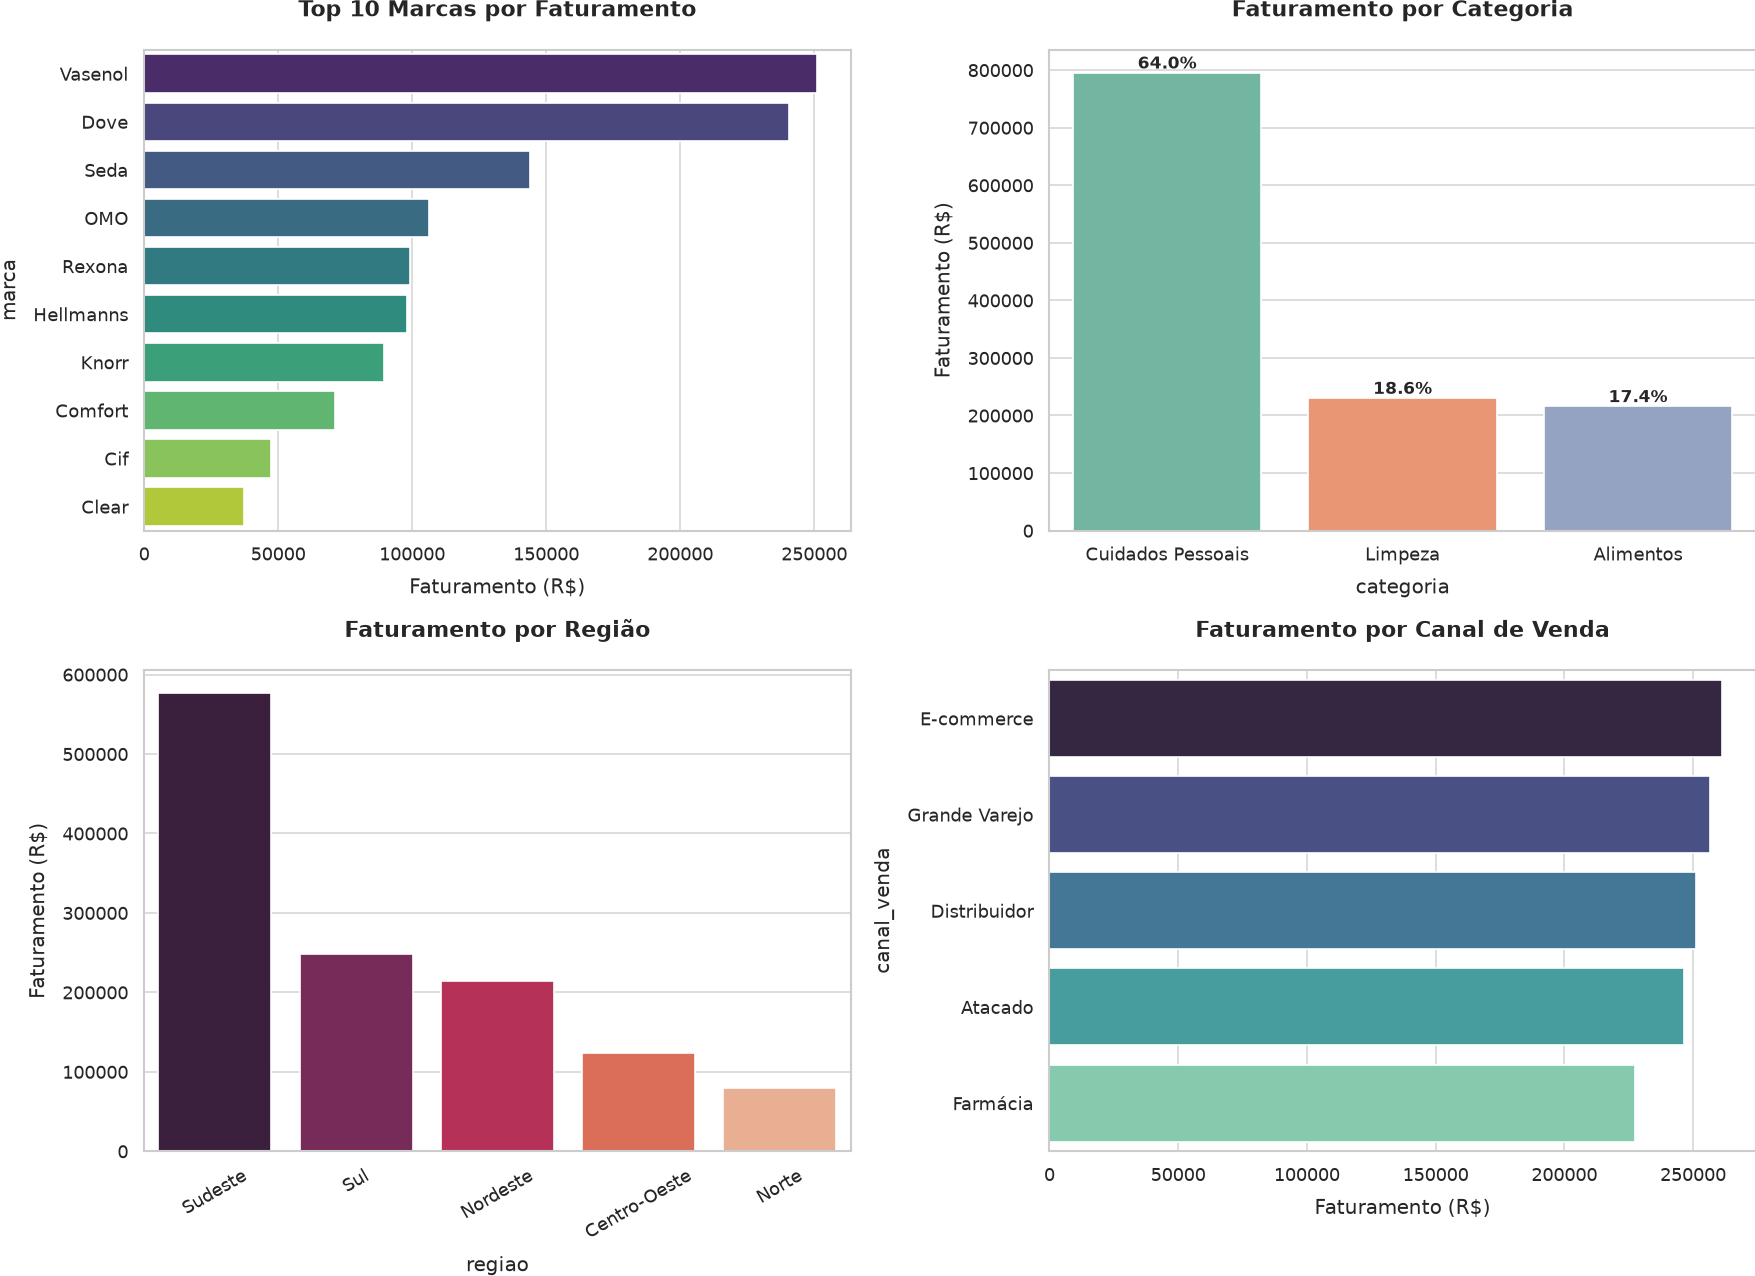

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Faturamento por marca (top 10)
fat_marca = pedidos.groupby("marca")["valor_total"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=fat_marca.values, y=fat_marca.index, hue=fat_marca.index,
            palette="viridis", legend=False, ax=axes[0,0])
axes[0,0].set_title("Top 10 Marcas por Faturamento")
axes[0,0].set_xlabel("Faturamento (R$)")

# Faturamento por categoria
fat_cat = pedidos.groupby("categoria")["valor_total"].sum().sort_values(ascending=False)
sns.barplot(x=fat_cat.index, y=fat_cat.values, hue=fat_cat.index,
            palette="Set2", legend=False, ax=axes[0,1])
total_cat = fat_cat.sum()
for i, v in enumerate(fat_cat.values):
    axes[0,1].text(i, v, f"{v/total_cat*100:.1f}%", ha="center", va="bottom",
                   fontsize=10, fontweight="bold")
axes[0,1].set_title("Faturamento por Categoria")
axes[0,1].set_ylabel("Faturamento (R$)")

# Faturamento por região
fat_reg = pedidos.groupby("regiao")["valor_total"].sum().sort_values(ascending=False)
sns.barplot(x=fat_reg.index, y=fat_reg.values, hue=fat_reg.index,
            palette="rocket", legend=False, ax=axes[1,0])
axes[1,0].set_title("Faturamento por Região")
axes[1,0].set_ylabel("Faturamento (R$)")
axes[1,0].tick_params(axis="x", rotation=30)

# Faturamento por canal
fat_can = pedidos.groupby("canal_venda")["valor_total"].sum().sort_values(ascending=False)
sns.barplot(x=fat_can.values, y=fat_can.index, hue=fat_can.index,
            palette="mako", legend=False, ax=axes[1,1])
axes[1,1].set_title("Faturamento por Canal de Venda")
axes[1,1].set_xlabel("Faturamento (R$)")

plt.tight_layout()
plt.savefig("../docs/img/04_vendas.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
# Top 3 SKUs por categoria (líderes de faturamento)
top_sku = (pedidos.groupby(["categoria","marca","sku"])["valor_total"].sum()
           .reset_index().sort_values(["categoria","valor_total"], ascending=[True, False]))
top_sku["rank"] = top_sku.groupby("categoria")["valor_total"].rank(method="first", ascending=False)
top3 = top_sku[top_sku["rank"] <= 3].copy()
top3["valor_total"] = top3["valor_total"].round(2)
top3[["categoria","rank","marca","sku","valor_total"]].reset_index(drop=True)

,categoria,rank,marca,sku,valor_total
0,Alimentos,1.0,Hellmanns,SKU0020,93808.8
1,Alimentos,2.0,Knorr,SKU0018,81553.8
2,Alimentos,3.0,Ades,SKU0023,14196.6
3,Cuidados Pessoais,1.0,Vasenol,SKU0007,228173.4
4,Cuidados Pessoais,2.0,Dove,SKU0002,207480.6
5,Cuidados Pessoais,3.0,Rexona,SKU0005,98560.8
6,Limpeza,1.0,Comfort,SKU0015,71130.6
7,Limpeza,2.0,OMO,SKU0013,64638.0
8,Limpeza,3.0,Cif,SKU0016,47223.0


## 5️⃣ Análise de Sazonalidade

Como o faturamento evolui mês a mês? Existe tendência de crescimento ou queda?
Essa análise é o **input principal do processo de forecast** em Demand Planning.

Variação mensal (%):
ano_mes
2025-01     0.0
2025-02     9.4
2025-03    -3.1
2025-04    -0.3
2025-05    -5.0
2025-06   -15.3


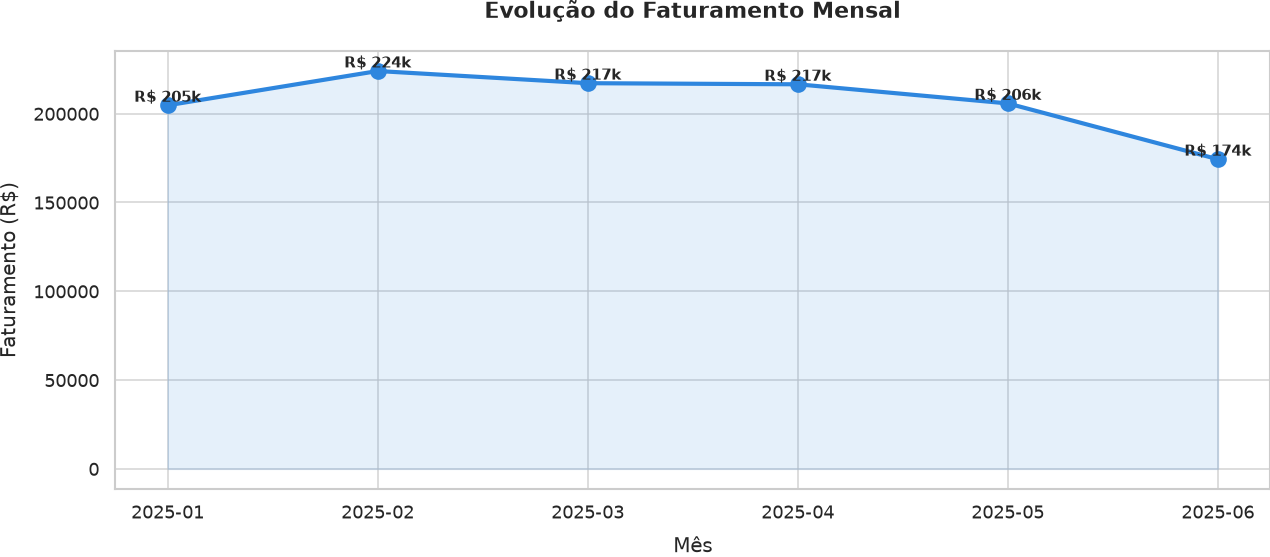

In [11]:
vendas_mes = pedidos.groupby("ano_mes")["valor_total"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vendas_mes.index, vendas_mes.values, marker="o", linewidth=2.5,
        color="#2E86DE", markersize=9)
ax.fill_between(range(len(vendas_mes)), vendas_mes.values, alpha=0.12, color="#2E86DE")
ax.set_title("Evolução do Faturamento Mensal")
ax.set_xlabel("Mês"); ax.set_ylabel("Faturamento (R$)")
for i, v in enumerate(vendas_mes.values):
    ax.text(i, v, f"R$ {v/1000:.0f}k", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/img/05_sazonalidade.png", dpi=120, bbox_inches="tight")
plt.show()

# Variação percentual mês a mês
var = vendas_mes.pct_change().mul(100).round(1)
print("Variação mensal (%):")
print(var.fillna(0).to_string())

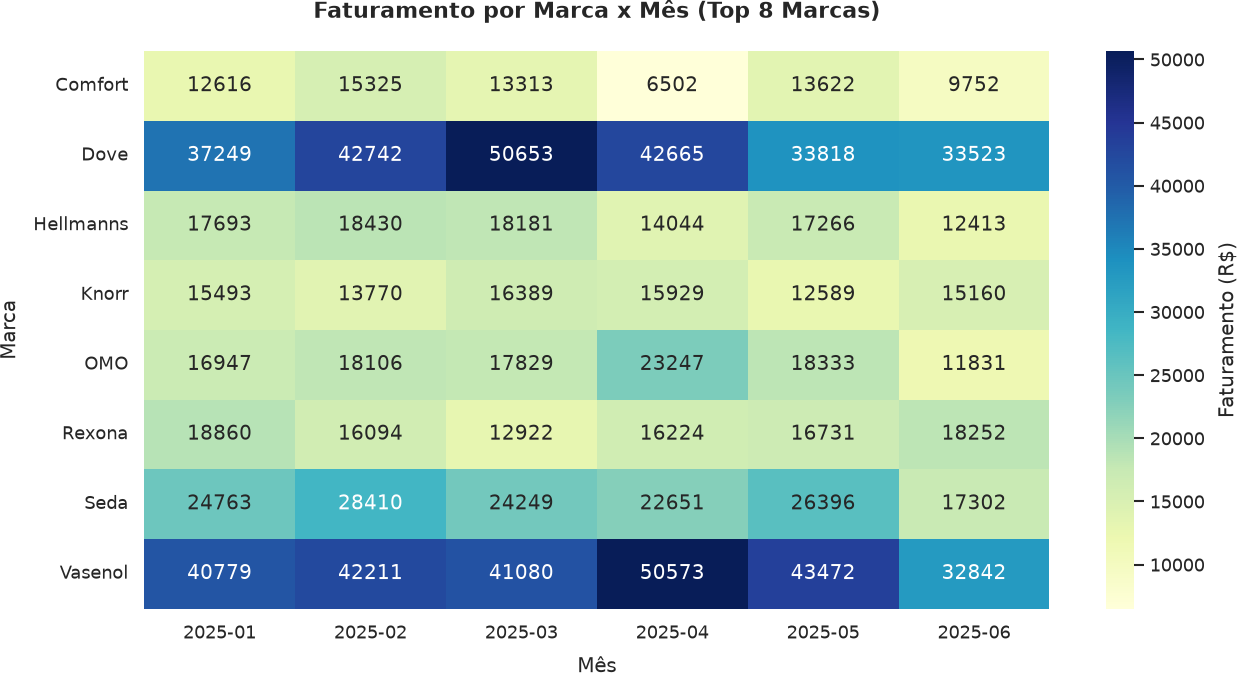

In [12]:
# Heatmap: faturamento por marca ao longo dos meses (top 8 marcas)
top_marcas = pedidos.groupby("marca")["valor_total"].sum().nlargest(8).index
pivot = (pedidos[pedidos["marca"].isin(top_marcas)]
         .pivot_table(index="marca", columns="ano_mes", values="valor_total", aggfunc="sum"))

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "Faturamento (R$)"})
ax.set_title("Faturamento por Marca x Mês (Top 8 Marcas)")
ax.set_xlabel("Mês"); ax.set_ylabel("Marca")
plt.tight_layout()
plt.savefig("../docs/img/05_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 6️⃣ Análise de Ruptura de Estoque

Ruptura = quando o estoque disponível cai abaixo do **ponto de reposição**.
Vamos olhar a posição **mais recente** de estoque e identificar os SKUs em risco.

In [13]:
# Posição de estoque mais recente
ultima_data = estoque["data_referencia"].max()
estoque_atual = estoque[estoque["data_referencia"] == ultima_data].copy()
print(f"Posição de estoque de referência: {ultima_data.date()}\n")

# % de SKUs em risco
n_risco = (estoque_atual["status_ruptura"] == "EM RISCO").sum()
print(f"SKUs em risco de ruptura: {n_risco} de {len(estoque_atual)} "
      f"({n_risco/len(estoque_atual)*100:.1f}%)")

Posição de estoque de referência: 2025-06-25

SKUs em risco de ruptura: 7 de 25 (28.0%)


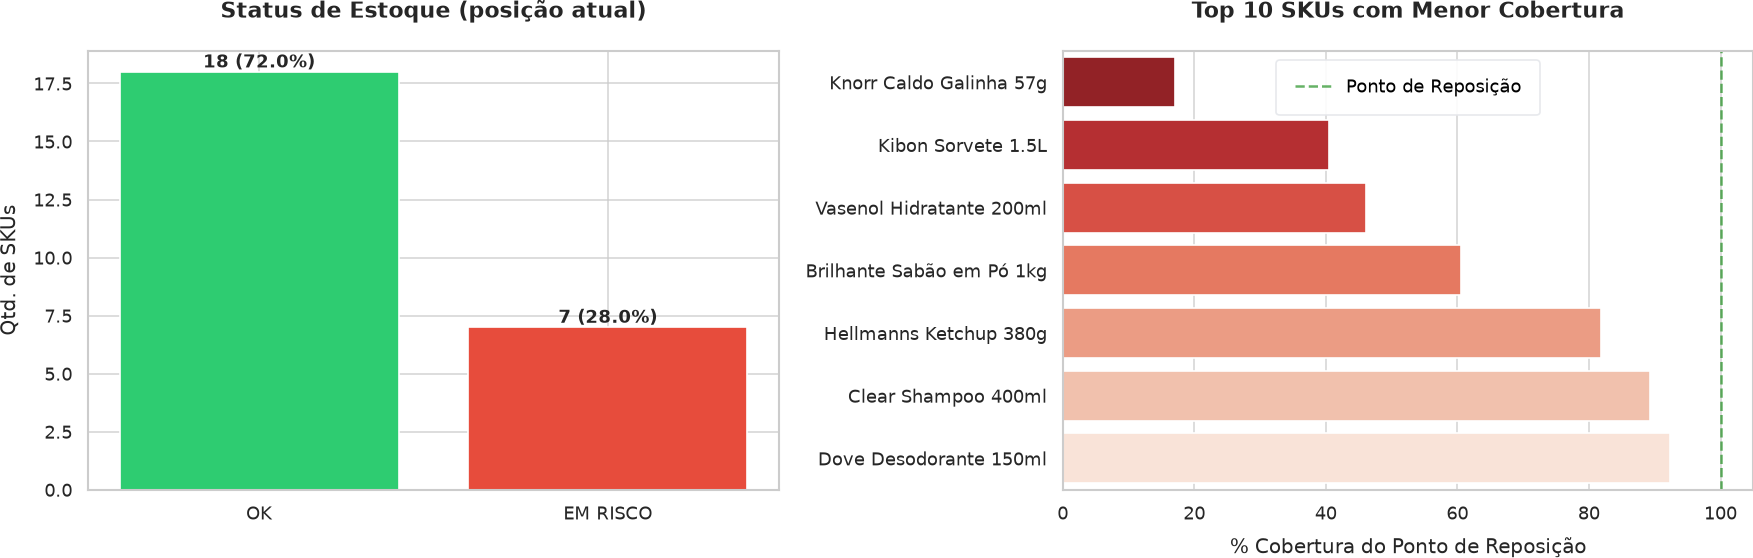

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição de status
status_cnt = estoque_atual["status_ruptura"].value_counts()
cores_status = {"EM RISCO": "#E74C3C", "OK": "#2ECC71"}
bars = axes[0].bar(status_cnt.index, status_cnt.values,
                   color=[cores_status.get(s, "#888") for s in status_cnt.index])
total_status = status_cnt.sum()
for b, v in zip(bars, status_cnt.values):
    axes[0].text(b.get_x()+b.get_width()/2, v, f"{v} ({v/total_status*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Status de Estoque (posição atual)")
axes[0].set_ylabel("Qtd. de SKUs")

# Top 10 SKUs com menor cobertura
em_risco = estoque_atual[estoque_atual["status_ruptura"] == "EM RISCO"].copy()
em_risco = em_risco.merge(produtos[["sku","descricao_produto"]], on="sku")
top_risco = em_risco.nsmallest(10, "pct_cobertura")
sns.barplot(x="pct_cobertura", y="descricao_produto", data=top_risco,
            hue="descricao_produto", palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title("Top 10 SKUs com Menor Cobertura")
axes[1].set_xlabel("% Cobertura do Ponto de Reposição")
axes[1].set_ylabel("")
axes[1].axvline(100, color="green", linestyle="--", alpha=0.6, label="Ponto de Reposição")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/img/06_ruptura.png", dpi=120, bbox_inches="tight")
plt.show()

## 7️⃣ Performance de Entrega (OTIF)

**OTIF** (On Time In Full) — aqui simplificado como "% de pedidos entregues no prazo".
É um dos KPIs mais importantes de Supply Chain.

OTIF geral: 84.0%



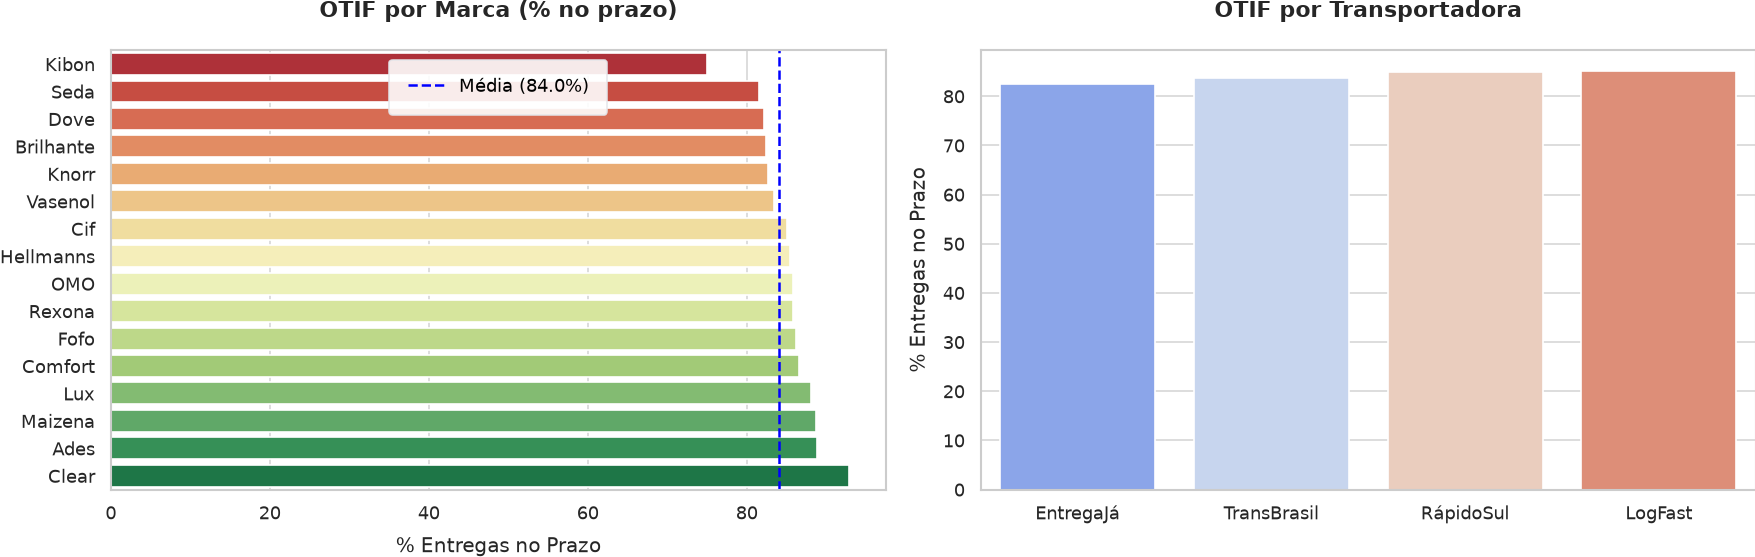

In [15]:
# Junta entregas com marca
ent = entregas.merge(pedidos[["id_pedido","marca"]].drop_duplicates(), on="id_pedido", how="left")
ent_valid = ent[ent["status_entrega"] != "Pendente"]

otif_geral = ent_valid["entrega_no_prazo"].mean() * 100
print(f"OTIF geral: {otif_geral:.1f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# OTIF por marca
otif_marca = (ent_valid.groupby("marca")["entrega_no_prazo"].mean()*100).sort_values()
sns.barplot(x=otif_marca.values, y=otif_marca.index, hue=otif_marca.index,
            palette="RdYlGn", legend=False, ax=axes[0])
axes[0].axvline(otif_geral, color="blue", linestyle="--", label=f"Média ({otif_geral:.1f}%)")
axes[0].set_title("OTIF por Marca (% no prazo)")
axes[0].set_xlabel("% Entregas no Prazo"); axes[0].set_ylabel("")
axes[0].legend()

# OTIF por transportadora
otif_transp = (ent_valid.groupby("transportadora")["entrega_no_prazo"].mean()*100).sort_values()
sns.barplot(x=otif_transp.index, y=otif_transp.values, hue=otif_transp.index,
            palette="coolwarm", legend=False, ax=axes[1])
axes[1].set_title("OTIF por Transportadora")
axes[1].set_ylabel("% Entregas no Prazo"); axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../docs/img/07_otif.png", dpi=120, bbox_inches="tight")
plt.show()

Atraso médio (quando atrasa): 4.0 dias
Atraso máximo: 7.0 dias


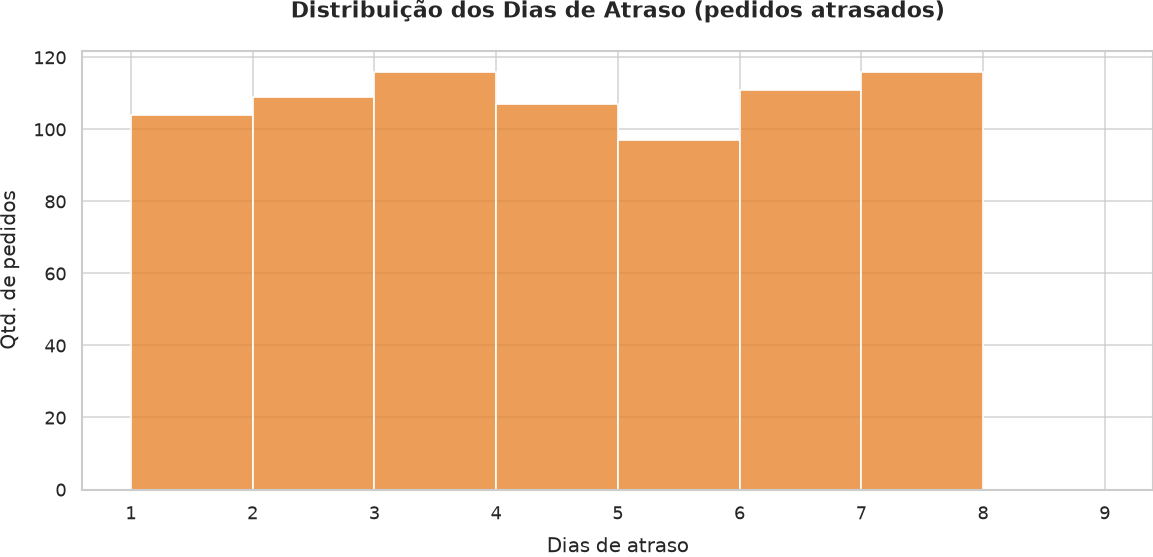

In [16]:
# Distribuição do atraso (apenas pedidos atrasados)
atrasados = ent_valid[ent_valid["atraso_dias"] > 0]
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(atrasados["atraso_dias"], bins=range(1,10), kde=False, ax=ax, color="#E67E22")
ax.set_title("Distribuição dos Dias de Atraso (pedidos atrasados)")
ax.set_xlabel("Dias de atraso"); ax.set_ylabel("Qtd. de pedidos")
plt.tight_layout()
plt.savefig("../docs/img/07_atraso.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Atraso médio (quando atrasa): {atrasados['atraso_dias'].mean():.1f} dias")
print(f"Atraso máximo: {atrasados['atraso_dias'].max()} dias")

## 8️⃣ SKUs Críticos — Demanda x Estoque

Aqui está o coração da análise: cruzamos **demanda histórica** com a **posição atual de
estoque**. SKUs com alta demanda E baixa cobertura são os que exigem ação imediata.

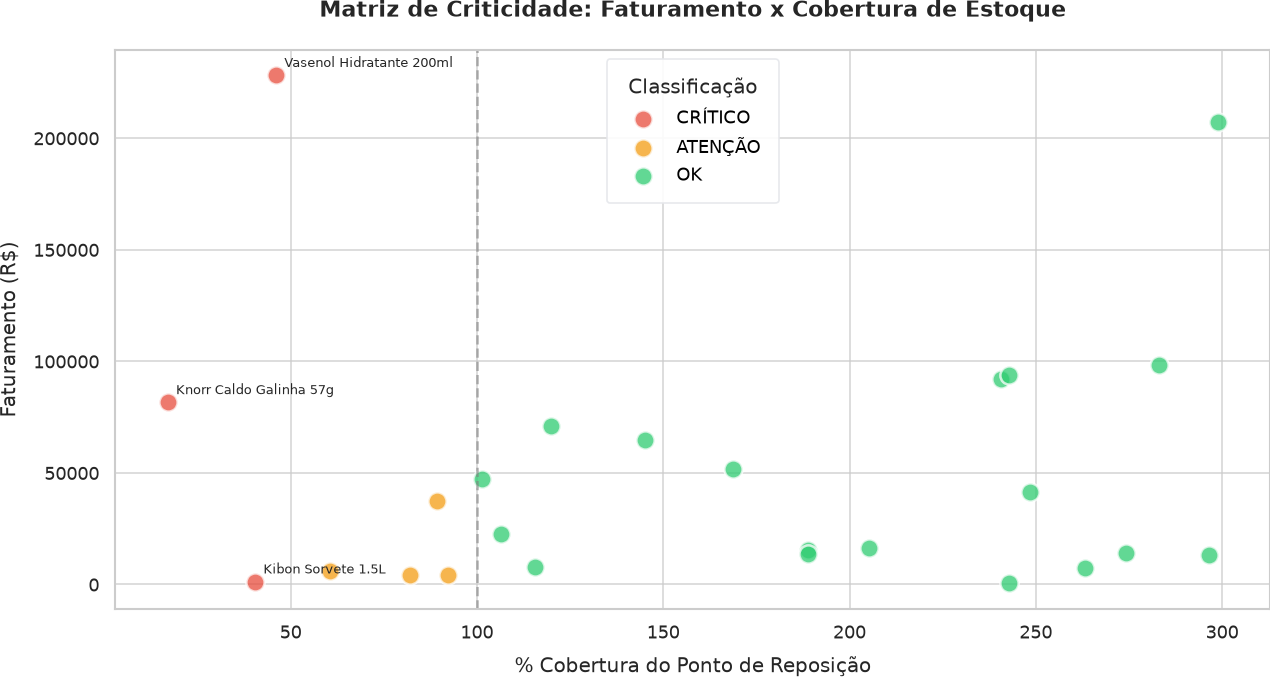

In [17]:
# Demanda por SKU
demanda = pedidos.groupby("sku").agg(
    qtd_vendida=("quantidade","sum"),
    faturamento=("valor_total","sum")).reset_index()

# Junta com estoque atual e produto
critico = demanda.merge(
    estoque_atual[["sku","quantidade_disponivel","pct_cobertura"]], on="sku")
critico = critico.merge(produtos[["sku","descricao_produto","marca","categoria"]], on="sku")

# Classificação de risco
def classifica(p):
    if p < 50: return "CRÍTICO"
    elif p < 100: return "ATENÇÃO"
    return "OK"
critico["classificacao"] = critico["pct_cobertura"].apply(classifica)

# Scatter: demanda vs cobertura
fig, ax = plt.subplots(figsize=(11, 6))
cores = {"CRÍTICO":"#E74C3C","ATENÇÃO":"#F39C12","OK":"#2ECC71"}
for cls, cor in cores.items():
    sub = critico[critico["classificacao"] == cls]
    ax.scatter(sub["pct_cobertura"], sub["faturamento"], s=120, alpha=0.75,
               color=cor, label=cls, edgecolors="white", linewidth=1.5)
ax.axvline(100, color="gray", linestyle="--", alpha=0.6)
ax.set_title("Matriz de Criticidade: Faturamento x Cobertura de Estoque")
ax.set_xlabel("% Cobertura do Ponto de Reposição")
ax.set_ylabel("Faturamento (R$)")
ax.legend(title="Classificação")
# rotula os mais críticos
for _, r in critico[critico["classificacao"]=="CRÍTICO"].iterrows():
    ax.annotate(r["descricao_produto"], (r["pct_cobertura"], r["faturamento"]),
                fontsize=8, xytext=(5,5), textcoords="offset points")
plt.tight_layout()
plt.savefig("../docs/img/08_criticos.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
# Tabela dos SKUs que exigem ação (abaixo do ponto de reposição), ordenada por faturamento
acao = critico[critico["pct_cobertura"] < 100].sort_values("faturamento", ascending=False)
acao_view = acao[["descricao_produto","marca","categoria","qtd_vendida",
                  "faturamento","pct_cobertura","classificacao"]].copy()
acao_view["faturamento"] = acao_view["faturamento"].round(2)
acao_view.reset_index(drop=True)

,descricao_produto,marca,categoria,qtd_vendida,faturamento,pct_cobertura,classificacao
0,Vasenol Hidratante 200ml,Vasenol,Cuidados Pessoais,11466,228173.4,46.06,CRÍTICO
1,Knorr Caldo Galinha 57g,Knorr,Alimentos,28122,81553.8,16.99,CRÍTICO
2,Clear Shampoo 400ml,Clear,Cuidados Pessoais,1566,37427.4,89.31,ATENÇÃO
3,Brilhante Sabão em Pó 1kg,Brilhante,Limpeza,342,5985.0,60.55,ATENÇÃO
4,Dove Desodorante 150ml,Dove,Cuidados Pessoais,234,4329.0,92.34,ATENÇÃO
5,Hellmanns Ketchup 380g,Hellmanns,Alimentos,474,4218.6,81.90,ATENÇÃO
6,Kibon Sorvete 1.5L,Kibon,Alimentos,48,1195.2,40.44,CRÍTICO


## 9️⃣ Bônus — Previsão Simples de Demanda (Média Móvel)

Uma primeira aproximação de forecast usando **média móvel**. Não é um modelo sofisticado,
mas mostra como transformar histórico em uma projeção simples — ótimo ponto de partida
para depois evoluir para modelos estatísticos (ARIMA, Prophet, etc.).

Previsão de demanda para o próximo mês: 16,089 unidades


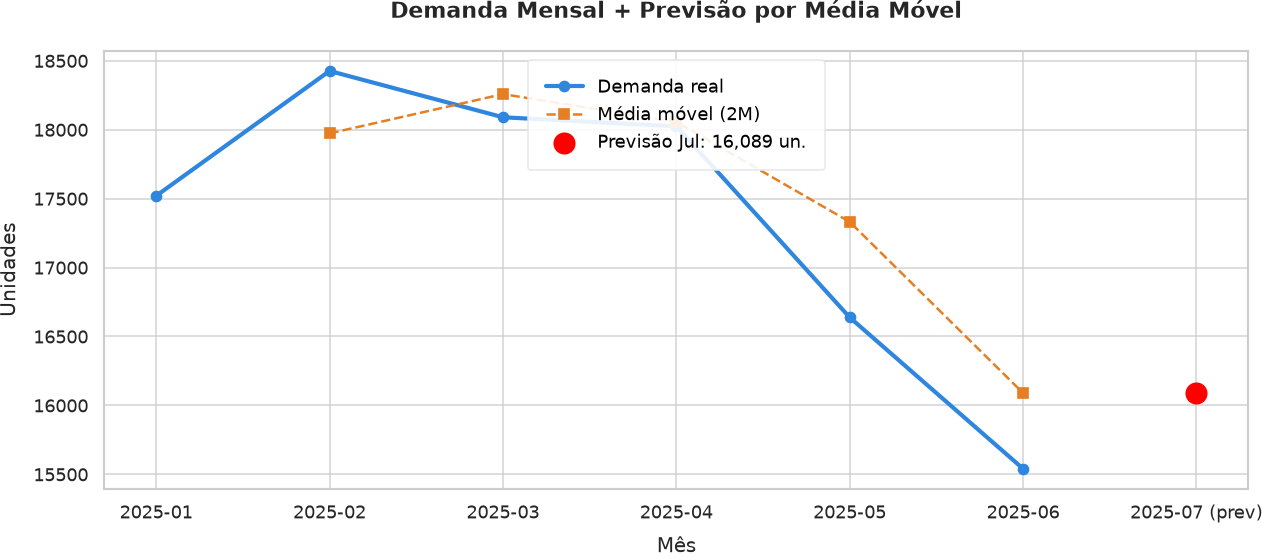

In [19]:
# Demanda mensal total (unidades)
demanda_mes = pedidos.groupby("ano_mes")["quantidade"].sum()

# Média móvel de 2 períodos
mm = demanda_mes.rolling(window=2).mean()
# Previsão do próximo mês = média dos 2 últimos
prev_prox = demanda_mes.tail(2).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(demanda_mes.index, demanda_mes.values, marker="o", label="Demanda real",
        linewidth=2.5, color="#2E86DE")
ax.plot(mm.index, mm.values, marker="s", linestyle="--", label="Média móvel (2M)",
        color="#E67E22")
# ponto de previsão
ax.scatter(["2025-07 (prev)"], [prev_prox], color="red", s=150, zorder=5,
           label=f"Previsão Jul: {prev_prox:,.0f} un.")
ax.set_title("Demanda Mensal + Previsão por Média Móvel")
ax.set_xlabel("Mês"); ax.set_ylabel("Unidades")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/img/09_forecast.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Previsão de demanda para o próximo mês: {prev_prox:,.0f} unidades")

## 🎯 Insights e Recomendações

> Esta é a seção que **mais importa** num projeto de análise de dados: transformar números
> em decisões de negócio.

### 📌 Principais achados

1. **Concentração de faturamento** — Categoria de **Cuidados Pessoais** lidera o faturamento,
   puxada por marcas como **Vasenol** e **Dove**. A região **Sudeste** concentra a maior fatia
   das vendas, o que faz sentido dado o peso econômico da região.

2. **Sazonalidade** — Observa-se uma **tendência de crescimento** ao longo do primeiro semestre,
   com pico em junho. Isso deve ser considerado no planejamento de estoque dos meses seguintes.

3. **Risco de ruptura** — Cerca de **1 em cada 5 SKUs** está abaixo do ponto de reposição na
   posição mais recente. Alguns produtos de **alto faturamento** estão em zona de atenção/crítica.

4. **Performance de entrega** — O OTIF geral está na casa dos **80-85%**, com variação relevante
   entre marcas e transportadoras. Há espaço claro de melhoria no SLA logístico.

5. **SKUs críticos** — A matriz de criticidade destaca produtos que combinam **alta demanda +
   baixa cobertura de estoque** — são a prioridade máxima para reposição.

### ✅ Recomendações acionáveis

- 🔴 **Reposição prioritária** dos SKUs classificados como `CRÍTICO`, especialmente os de alto
  faturamento — o custo de ruptura aqui é o mais alto.
- 📦 **Revisar contratos** com as transportadoras de pior OTIF e renegociar prazos.
- 📈 **Ajustar o forecast** considerando a tendência de alta do semestre para evitar rupturas futuras.
- 🎯 **Foco comercial** nas marcas/categorias líderes, mantendo disponibilidade alta desses itens.

### 🚀 Próximos passos (evolução do projeto)

- Substituir a média móvel por um **modelo de forecast** mais robusto (Prophet, ARIMA).
- Migrar o processamento para **PySpark** para lidar com volumes maiores.
- Construir um **dashboard interativo** (Power BI) para consumo pelo time de negócio.
- Automatizar a atualização com um **orquestrador** (Airflow).

---

**Felipe Comenale Banciella** · [LinkedIn](https://www.linkedin.com/in/felipe-banciella) · [GitHub](https://github.com/felipe-banciella)
